<a href="https://colab.research.google.com/github/DineshYadav06/AI-based-system-for-recognizing-Indian-cattle-and-buffalo-breeds-/blob/main/efficient_netB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
dataset_path = '/content/drive/MyDrive/Cattle_Breed_workspace/Kaggle_Datasets/cattle_breeds/PNG Breeds'

In [ ]:
# Image config – B7 ke liye 600 size
img_size = 600
batch_size = 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Data augmentation – images ko thoda random modify karke training strong
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

Found 969 images belonging to 5 classes.
Found 239 images belonging to 5 classes.


In [ ]:
# Pretrained EfficientNet-B7 load – feature extractor
base_model = EfficientNetB7(
    weights='imagenet',
    include_top=False,
    input_shape=(600,600,3)
)

base_model.trainable = False  # pehle freeze


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Custom classifier head – apna cattle breed output layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(num_classes, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
# Compile – model ko training ke liye ready
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Callbacks – auto stop + learning rate adjust
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import Callback

In [ ]:

class ClassificationReportCallback(Callback):
    def __init__(self, val_generator):
        super().__init__()
        self.val_generator = val_generator

    def on_epoch_end(self, epoch, logs=None):
        print("\n📊 Classification Report - Epoch:", epoch+1)

        self.val_generator.reset()

        preds = self.model.predict(self.val_generator, verbose=0)

        y_pred = np.argmax(preds, axis=1)
        y_true = self.val_generator.classes

        print(classification_report(
            y_true,
            y_pred,
            target_names=list(self.val_generator.class_indices.keys())
        ))

In [ ]:
report_callback = ClassificationReportCallback(val_generator)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[report_callback]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4026 - loss: 1.4388
📊 Classification Report - Epoch: 1
                          precision    recall  f1-score   support

         Ayrshire cattle       0.31      0.27      0.29        52
      Brown Swiss cattle       0.13      0.15      0.14        47
Holstein Friesian cattle       0.09      0.12      0.10        50
           Jersey cattle       0.30      0.22      0.25        50
         Red Dane cattle       0.14      0.12      0.13        40

                accuracy                           0.18       239
               macro avg       0.19      0.18      0.18       239
            weighted avg       0.20      0.18      0.19       239

243/243 ━━━━━━━━━━━━━━━━━━━━ 760s 3s/step - accuracy: 0.4032 - loss: 1.4380 - val_accuracy: 0.7155 - val_loss: 1.0088
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6811 - loss: 0.9300
📊 Classification Report - Epoch: 2
                          precision    rec

In [ ]:
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[13 11  9 10  9]
 [ 3  9 15  7 13]
 [13  6  8 11 12]
 [ 9  7 17  9  8]
 [10  8 10  7  5]]


In [ ]:
# Fine tuning – last 80 layers train kar rahe
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.7129 - loss: 0.7779 - val_accuracy: 0.7155 - val_loss: 0.7546 - learning_rate: 1.0000e-05
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 137s 564ms/step - accuracy: 0.8035 - loss: 0.5862 - val_accuracy: 0.7448 - val_loss: 0.7253 - learning_rate: 1.0000e-05
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 138s 568ms/step - accuracy: 0.8075 - loss: 0.5728 - val_accuracy: 0.7531 - val_loss: 0.7289 - learning_rate: 1.0000e-05
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 137s 563ms/step - accuracy: 0.8421 - loss: 0.4510 - val_accuracy: 0.7782 - val_loss: 0.6481 - learning_rate: 1.0000e-05
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 136s 559ms/step - accuracy: 0.8636 - loss: 0.4252 - val_accuracy: 0.7699 - val_loss: 0.7164 - learning_rate: 1.0000e-05
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 137s 562ms/step - accuracy: 0.8567 - loss: 0.4176 - val_accuracy: 0.7657 - val_loss: 0.7067 - learning_rate: 1.0000e-05
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 136

In [ ]:
# Predictions nikal rahe – model se output le rahe
val_generator.reset()

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

class_names = list(val_generator.class_indices.keys())


60/60 ━━━━━━━━━━━━━━━━━━━━ 71s 792ms/step


In [ ]:
# Predictions nikal rahe – model se output le rahe
val_generator.reset()

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

class_names = list(val_generator.class_indices.keys())


60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 415ms/step


In [ ]:
# Classification report – precision, recall, f1-score
print(classification_report(y_true, y_pred_classes, target_names=class_names))


                          precision    recall  f1-score   support

         Ayrshire cattle       0.27      0.25      0.26        52
      Brown Swiss cattle       0.22      0.19      0.20        47
Holstein Friesian cattle       0.14      0.16      0.15        50
           Jersey cattle       0.20      0.18      0.19        50
         Red Dane cattle       0.11      0.12      0.11        40

                accuracy                           0.18       239
               macro avg       0.19      0.18      0.18       239
            weighted avg       0.19      0.18      0.19       239



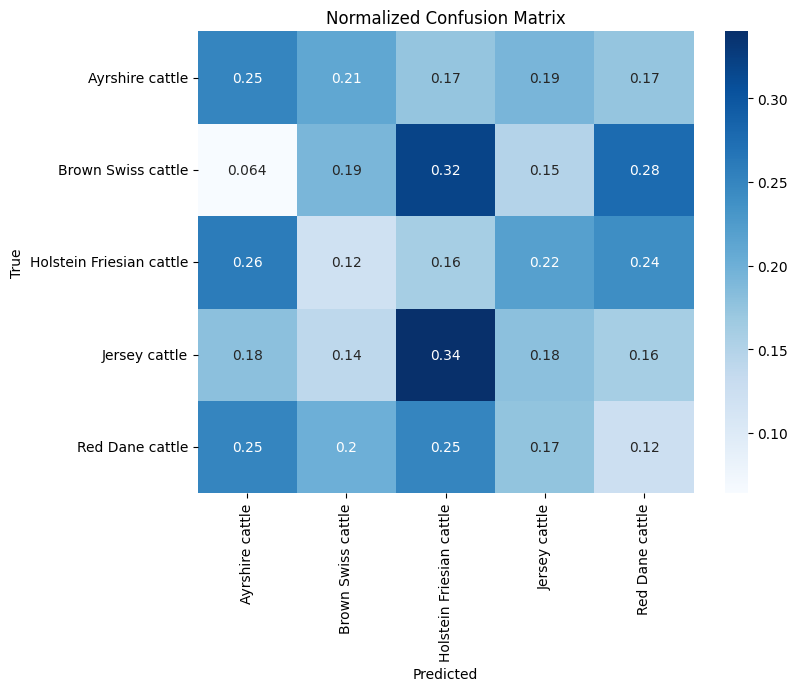

In [ ]:
# Confusion matrix – actual vs predicted check
cm = confusion_matrix(y_true, y_pred_classes)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized,
            annot=True,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()


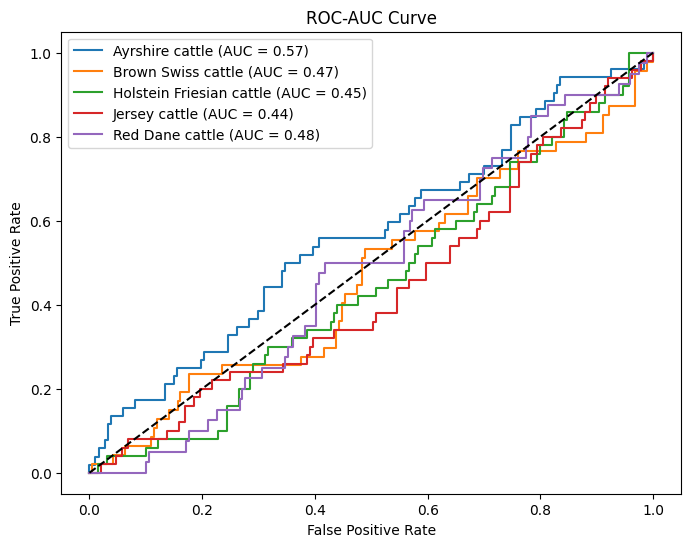

In [ ]:
# ROC-AUC curve – har class ka performance
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()


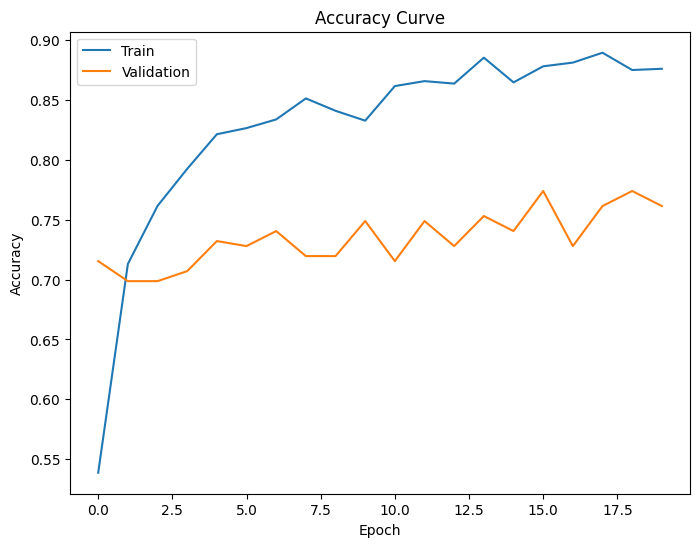

In [ ]:
# Accuracy curve – training vs validation
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()


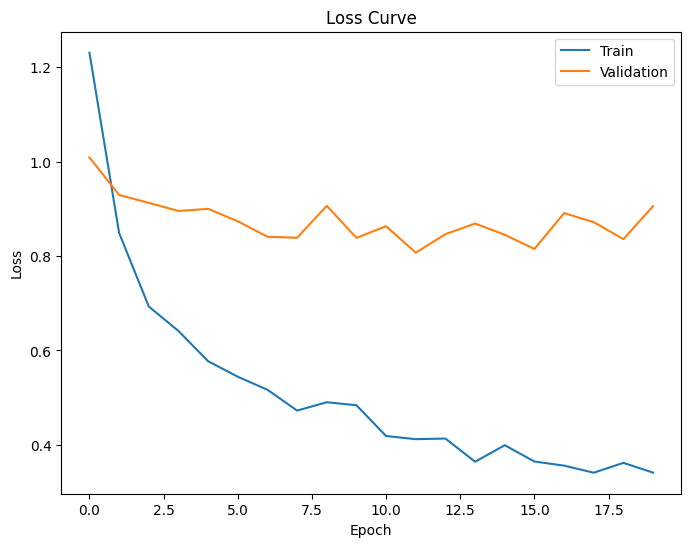

In [ ]:
# Loss curve – overfitting check
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()
